In [25]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sb

In [26]:
np.random.seed(42)

In [27]:
df = pd.read_csv("dataset/mnist_train.csv")
print(df.isna().sum().sum())
df

0


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
X_raw = df.drop("label",axis=1).to_numpy()

X_mean = np.mean(X_raw, axis=0)
X_std = np.std(X_raw, axis=0)

epsilon = 1e-8
X = (X_raw - X_mean) / (X_std + epsilon) # Z-score normalization

In [29]:

Y_raw = df["label"].to_numpy()

number_of_classes = 10
Y = np.eye(number_of_classes)[Y_raw] # One-hot encoding 

In [ ]:
class multilayer_perceptron:
    def __init__(self, layer_neurons, activations, learning_rate, epochs, batch_size, keep_prob=0.8):
        self.layers_n = layer_neurons
        self.activations = activations + ['softmax']
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.keep_prob = keep_prob

        self.results = []
        self.val_results = []       
        self.accuracy = []
        self.val_accuracy = []

        # Initialize Weights and Biases
        self.W = []
        self.b = []
        for i in range(len(layer_neurons)-1):
            n_in = layer_neurons[i]
            n_out = layer_neurons[i+1]
            
            if self.activations[i] == 'relu':
                scale = np.sqrt(2.0 / n_in)  # He Initialization
            else:
                scale = np.sqrt(1.0 / n_in)  # Xavier/Glorot Initialization
                
            self.W.append(np.random.randn(n_in, n_out) * scale)
            self.b.append(np.zeros((1, n_out)))
        
        self.activation_funcs = {'relu': self.ReLU, 'tanh': self.tanh, 'softmax': self.softmax}
        self.activation_derivatives = {'relu': self.ReLU_derivative, 'tanh': self.tanh_derivative}

    # --- Activation Functions ---
    def ReLU(self, X): 
        return np.maximum(0, X)
    
    def ReLU_derivative(self, Z): 
        return (Z > 0) * 1.0

    def tanh(self, X):
        a = np.exp(np.clip(X, -500, 500))
        b = np.exp(-np.clip(X, -500, 500))
        return (a - b) / (a + b)

    def tanh_derivative(self, Z): 
        A_clean = self.tanh(Z)
        return 1.0 - A_clean**2 

    def softmax(self, X):
        row_maxes = np.max(X, axis=1, keepdims=True)
        shifted_X = X - row_maxes
        exp_X = np.exp(shifted_X)
        return exp_X / np.sum(exp_X, axis=1, keepdims=True)

    # --- Forward Propagation ---
    def feed_forward(self, X, training=False):
        self.A = [X]
        self.Z = []
        self.masks = []  
        
        for i in range(len(self.W)):
            z = np.dot(self.A[i], self.W[i]) + self.b[i]
            self.Z.append(z)
            a = self.activation_funcs[self.activations[i]](z)
            
            if training and i < len(self.W) - 1:
                mask = (np.random.rand(*a.shape) < self.keep_prob)
                a = (a * mask) / self.keep_prob
                self.masks.append(mask)
            else:
                self.masks.append(None)
                
            self.A.append(a)
            
        return self.A[-1]

    def _backpropagate(self, Y):
        total_samples = Y.shape[0]
        
        dW = [None] * len(self.W)
        db = [None] * len(self.b)
        
        # 1. Output error calculation
        dZ = self.A[-1] - Y
        
        # 2. Backward loop to calculate gradients
        for i in reversed(range(len(self.W))):
            dW[i] = np.dot(self.A[i].T, dZ) / total_samples
            db[i] = np.sum(dZ, axis=0, keepdims=True) / total_samples
            
            if i > 0:
                act_prev = self.activations[i-1]
                derivative = self.activation_derivatives[act_prev](self.Z[i-1])
                
                dZ = np.dot(dZ, self.W[i].T) * derivative
                
                if self.masks[i-1] is not None:
                    dZ = (dZ * self.masks[i-1]) / self.keep_prob
        
        
        for i in range(len(self.W)):
            self.W[i] -= self.lr * dW[i]
            self.b[i] -= self.lr * db[i]
    
    def compute_loss(self, Y_pred, Y_true):
        epsilon = 1e-15
        Y_pred = np.clip(Y_pred, epsilon, 1 - epsilon)
        return -np.sum(Y_true * np.log(Y_pred)) / Y_true.shape[0]
    
    def save_model(self, filename="fully_trained_mlp.pkl"):
        import pickle
        with open(filename, 'wb') as file:
            pickle.dump(self, file)
        print(f"--> Success! Entire model object exported to '{filename}'")

    @staticmethod
    def load_model(filename="fully_trained_mlp.pkl"):
        import pickle
        with open(filename, 'rb') as file:
            model = pickle.load(file)
        print(f"--> Success! Model object fully restored from '{filename}'")
        return model

    def fit(self, X, Y, X_val, Y_val, patience=3):
        total_samples = Y.shape[0]
        indices = np.arange(total_samples)

        best_val_loss = float('inf')
        patience_counter = 0

        for ep in range(self.epochs):
            np.random.shuffle(indices)
            X_shuffled = X[indices]
            Y_shuffled = Y[indices]

            for i in range(0, total_samples, self.batch_size):
                X_batch = X_shuffled[i : i + self.batch_size]
                Y_batch = Y_shuffled[i : i + self.batch_size]
                
                self.feed_forward(X_batch, training=True)
                self._backpropagate(Y_batch)            

            full_train_pred = self.feed_forward(X, training=False)
            full_val_pred = self.feed_forward(X_val, training=False) 
            
            train_loss = self.compute_loss(full_train_pred, Y)
            val_loss = self.compute_loss(full_val_pred, Y_val)
            
            self.results.append(train_loss)
            self.val_results.append(val_loss)
            
            train_acc = np.mean(np.argmax(full_train_pred, axis=1) == np.argmax(Y, axis=1)) * 100
            val_acc = np.mean(np.argmax(full_val_pred, axis=1) == np.argmax(Y_val, axis=1)) * 100
            
            self.accuracy.append(train_acc)
            self.val_accuracy.append(val_acc)
            
            print(f"Epoch {ep+1:02d}/{self.epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0 
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                print(f"\n[Early Stopping] Validation loss has stalled for {patience} epochs. Stopping training safely to prevent overfitting.")
                break

In [39]:

total_samples = X.shape[0]
split_index = int(total_samples * 0.8)  # 80% for training, 20% for validation

indices = np.arange(total_samples)
np.random.shuffle(indices)

# Slice into final Train and Validation subsets
X_train, X_val = X[indices[:split_index]], X[indices[split_index:]]
Y_train, Y_val = Y[indices[:split_index]], Y[indices[split_index:]]

In [68]:
mlp = multilayer_perceptron([784,512,128,10],['relu','tanh'],0.001,50,128,0.95)
mlp.fit(X_train,Y_train,X_val,Y_val)
# print(mlp.accuracy)

Epoch 01/50 | Train Loss: 0.0978 | Val Loss: 0.1412 | Val Acc: 95.63%
Epoch 02/50 | Train Loss: 0.0607 | Val Loss: 0.1156 | Val Acc: 96.45%
Epoch 03/50 | Train Loss: 0.0403 | Val Loss: 0.1045 | Val Acc: 96.63%
Epoch 04/50 | Train Loss: 0.0319 | Val Loss: 0.1038 | Val Acc: 96.84%
Epoch 05/50 | Train Loss: 0.0201 | Val Loss: 0.1042 | Val Acc: 96.97%
Epoch 06/50 | Train Loss: 0.0196 | Val Loss: 0.1070 | Val Acc: 97.01%
Epoch 07/50 | Train Loss: 0.0142 | Val Loss: 0.1015 | Val Acc: 96.99%
Epoch 08/50 | Train Loss: 0.0159 | Val Loss: 0.1073 | Val Acc: 96.99%
Epoch 09/50 | Train Loss: 0.0109 | Val Loss: 0.1031 | Val Acc: 97.22%
Epoch 10/50 | Train Loss: 0.0088 | Val Loss: 0.1030 | Val Acc: 97.34%

[Early Stopping] Validation loss has stalled for 3 epochs. Stopping training safely to prevent overfitting.


In [69]:
pred_val = mlp.feed_forward(X_val)
val_loss = mlp.compute_loss(pred_val, Y_val)
val_acc = np.sum(np.argmax(pred_val, axis=1) == np.argmax(Y_val, axis=1))

print(val_acc)

11681


In [ ]:
import time

learning_rate = 0.01
batch_size = 128
epochs = 15

arch_narrow = [784, 64, 32, 10]
arch_medium = [784, 256, 64, 10]
arch_wide   = [784, 512, 128, 10]

# -------------------------------------------------------------
# 1. Train Narrow Architecture
# -------------------------------------------------------------
print("Training Narrow Architecture [784, 64, 32, 10]...")
mlp_narrow = multilayer_perceptron(arch_narrow, learning_rate, epochs, batch_size)

start_time = time.time()
mlp_narrow.fit(X_train, Y_train)
time_narrow = time.time() - start_time

cost_narrow = [float(c) for c in mlp_narrow.results]
print(f"--> Narrow Training Complete in: {time_narrow:.2f} seconds\n")

# -------------------------------------------------------------
# 2. Train Medium Architecture
# -------------------------------------------------------------
print("Training Medium Architecture [784, 256, 64, 10]...")
mlp_medium = multilayer_perceptron(arch_medium, learning_rate, epochs, batch_size)

start_time = time.time()
mlp_medium.fit(X_train, Y_train)
time_medium = time.time() - start_time

cost_medium = [float(c) for c in mlp_medium.results]
print(f"--> Medium Training Complete in: {time_medium:.2f} seconds\n")

# -------------------------------------------------------------
# 3. Train Wide Architecture
# -------------------------------------------------------------
print("Training Wide Architecture [784, 512, 128, 10]...")
mlp_wide = multilayer_perceptron(arch_wide, learning_rate, epochs, batch_size)

start_time = time.time()
mlp_wide.fit(X_train, Y_train)
time_wide = time.time() - start_time

cost_wide = [float(c) for c in mlp_wide.results]
print(f"--> Wide Training Complete in: {time_wide:.2f} seconds\n")


# =============================================================
# CHART GENERATION: COST COMPARISON WITH TIMINGS
# =============================================================
plt.figure(figsize=(11, 6))

epochs_range = range(1, epochs + 1)

# Plot actual cost tracking vectors with added time metrics in the legends
plt.plot(epochs_range, cost_narrow, color='crimson', linestyle=':', linewidth=2, 
         label=f'Narrow [64, 32] | Cost: {cost_narrow[-1]:.4f} | Time: {time_narrow:.1f}s')

plt.plot(epochs_range, cost_medium, color='royalblue', linestyle='--', linewidth=2, 
         label=f'Medium [256, 64] | Cost: {cost_medium[-1]:.4f} | Time: {time_medium:.1f}s')

plt.plot(epochs_range, cost_wide, color='forestgreen', linestyle='-', linewidth=2.5, 
         label=f'Wide [512, 128] | Cost: {cost_wide[-1]:.4f} | Time: {time_wide:.1f}s')

# Chart Details & Polish
plt.title('Hyperparameter Report: Cross-Entropy Cost vs. Network Capacity', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Cross-Entropy Cost (Loss)', fontsize=12)
plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10, loc='upper right')

# Plot structural scatter points on final values
plt.scatter(epochs, cost_narrow[-1], color='crimson', zorder=5)
plt.scatter(epochs, cost_medium[-1], color='royalblue', zorder=5)
plt.scatter(epochs, cost_wide[-1], color='forestgreen', zorder=5)

plt.tight_layout()
plt.show()

Training Narrow Architecture [784, 64, 32, 10]...


TypeError: multilayer_perceptron.__init__() missing 1 required positional argument: 'batch_size'

=== VALIDATION DATA RESULTS ===
Narrow [64, 32]   -> Val Cost: 0.1945 | Val Accuracy: 94.23%
Medium [256, 64]  -> Val Cost: 0.1772 | Val Accuracy: 94.69%
Wide [512, 128]  -> Val Cost: 0.1666 | Val Accuracy: 95.03%



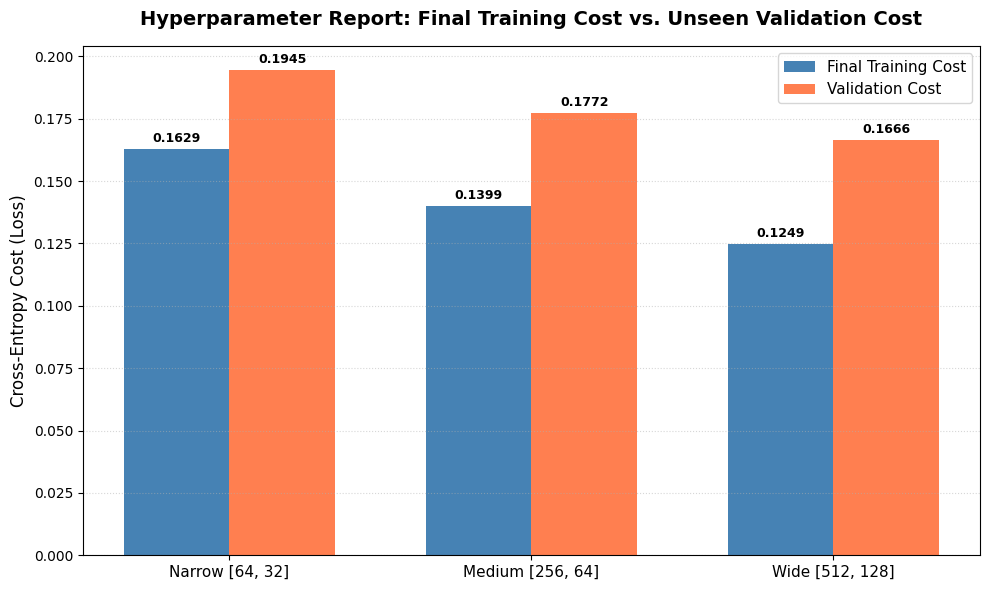

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1. Run Validation Pass for All Models
# -------------------------------------------------------------
# Narrow Model Validation
pred_val_narrow = mlp_narrow.feed_forward(X_val)
val_loss_narrow = mlp_narrow.compute_loss(pred_val_narrow, Y_val)
val_acc_narrow = np.mean(np.argmax(pred_val_narrow, axis=1) == np.argmax(Y_val, axis=1)) * 100

# Medium Model Validation
pred_val_medium = mlp_medium.feed_forward(X_val)
val_loss_medium = mlp_medium.compute_loss(pred_val_medium, Y_val)
val_acc_medium = np.mean(np.argmax(pred_val_medium, axis=1) == np.argmax(Y_val, axis=1)) * 100

# Wide Model Validation
pred_val_wide = mlp_wide.feed_forward(X_val)
val_loss_wide = mlp_wide.compute_loss(pred_val_wide, Y_val)
val_acc_wide = np.mean(np.argmax(pred_val_wide, axis=1) == np.argmax(Y_val, axis=1)) * 100

# Print clean console diagnostics
print("=== VALIDATION DATA RESULTS ===")
print(f"Narrow [64, 32]   -> Val Cost: {val_loss_narrow:.4f} | Val Accuracy: {val_acc_narrow:.2f}%")
print(f"Medium [256, 64]  -> Val Cost: {val_loss_medium:.4f} | Val Accuracy: {val_acc_medium:.2f}%")
print(f"Wide [512, 128]  -> Val Cost: {val_loss_wide:.4f} | Val Accuracy: {val_acc_wide:.2f}%\n")


# =============================================================
# CHART GENERATION: TRAIN VS VALIDATION LOSS COMPARISON
# =============================================================
# Set up data groups for side-by-side bars
labels = ['Narrow [64, 32]', 'Medium [256, 64]', 'Wide [512, 128]']
train_costs = [cost_narrow[-1], cost_medium[-1], cost_wide[-1]]
val_costs = [val_loss_narrow, val_loss_medium, val_loss_wide]

x = np.arange(len(labels))  # label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, train_costs, width, label='Final Training Cost', color='steelblue')
rects2 = ax.bar(x + width/2, val_costs, width, label='Validation Cost', color='coral')

# Add titles and labels
ax.set_ylabel('Cross-Entropy Cost (Loss)', fontsize=12)
ax.set_title('Hyperparameter Report: Final Training Cost vs. Unseen Validation Cost', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.grid(True, linestyle=':', alpha=0.5, axis='y')
ax.legend(fontsize=11)

# Attach text labels above each bar to show exact value
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

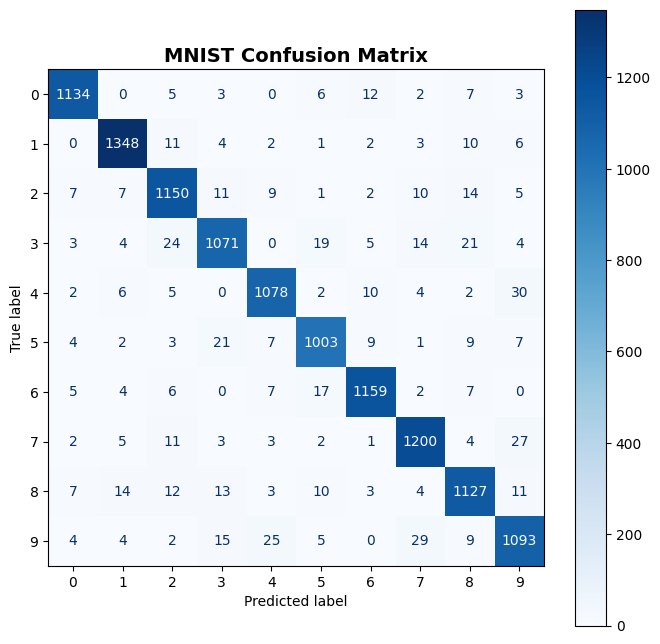

Total misclassified images in validation set: 637 out of 12000


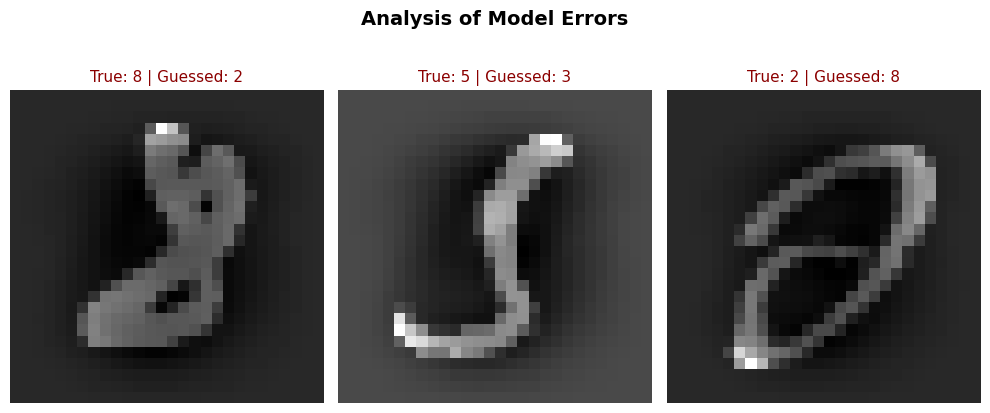

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

val_predictions = mlp_medium.feed_forward(X_val)
pred_digits = np.argmax(val_predictions, axis=1)
true_digits = np.argmax(Y_val, axis=1)

cm = confusion_matrix(true_digits, pred_digits)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('MNIST Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()

misclassified_indices = np.where(pred_digits != true_digits)[0]
print(f"Total misclassified images in validation set: {len(misclassified_indices)} out of {pred_digits.shape[0]}")

plt.figure(figsize=(10, 4))
for i, idx in enumerate(misclassified_indices[:3]):
    plt.subplot(1, 3, i + 1)
    img = X_val[idx].reshape(28, 28) 
    
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_digits[idx]} | Guessed: {pred_digits[idx]}", fontsize=11, color='darkred')
    plt.axis('off')

plt.suptitle('Analysis of Model Errors', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

class multilayer_perceptron_AdamOpt:
    def __init__(self, layer_neurons, activations, learning_rate, epochs, batch_size, keep_prob=0.8,beta1=0.9,beta2 = 0.999):
        self.layers_n = layer_neurons
        self.activations = activations + ['softmax']
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.keep_prob = keep_prob
        self.beta1 = 0.9
        self.beta2 = 0.999
        self.epsilon = 1e-8
        self.t = 0

        self.results = []
        self.val_results = []       
        self.accuracy = []
        self.val_accuracy = []

        self.W = []
        self.b = []
        for i in range(len(layer_neurons)-1):
            n_in = layer_neurons[i]
            n_out = layer_neurons[i+1]
            
            if self.activations[i] == 'relu':
                scale = np.sqrt(2.0 / n_in)  # He Initialization
            else:
                scale = np.sqrt(1.0 / n_in)  # Xavier/Glorot Initialization
                
            self.W.append(np.random.randn(n_in, n_out) * scale)
            self.b.append(np.zeros((1, n_out)))
            
        self.m_W = [np.zeros_like(w) for w in self.W]
        self.v_W = [np.zeros_like(w) for w in self.W]

        self.m_b = [np.zeros_like(b) for b in self.b]
        self.v_b = [np.zeros_like(b) for b in self.b]
        
        self.activation_funcs = {'relu': self.ReLU, 'tanh': self.tanh, 'softmax': self.softmax}
        self.activation_derivatives = {'relu': self.ReLU_derivative, 'tanh': self.tanh_derivative}
        

    # --- Activation Functions ---
    def ReLU(self, X): 
        return np.maximum(0, X)
    
    def ReLU_derivative(self, A): 
        return (A > 0) * 1.0

    def tanh(self, X):
        a = np.exp(np.clip(X, -500, 500))
        b = np.exp(-np.clip(X, -500, 500))
        return (a - b) / (a + b)

    def tanh_derivative(self, X): 
        A_clean = self.tanh(X)
        return 1.0 - A_clean**2 

    def softmax(self, X):
        row_maxes = np.max(X, axis=1, keepdims=True)
        shifted_X = X - row_maxes
        exp_X = np.exp(shifted_X)
        return exp_X / np.sum(exp_X, axis=1, keepdims=True)

    # --- Forward Propagation ---
    def feed_forward(self, X, training=False):
        self.A = [X]
        self.Z = []
        self.masks = []  
        
        for i in range(len(self.W)):
            z = np.dot(self.A[i], self.W[i]) + self.b[i]
            self.Z.append(z)
            a = self.activation_funcs[self.activations[i]](z)
            
            if training and i < len(self.W) - 1:
                mask = (np.random.rand(*a.shape) < self.keep_prob)
                a = (a * mask) / self.keep_prob
                self.masks.append(mask)
            else:
                self.masks.append(None)
                
            self.A.append(a)
            
        return self.A[-1]


    def _backpropagate(self, Y):
        total_samples = Y.shape[0]
        
        dW = [None] * len(self.W)
        db = [None] * len(self.b)
        
        dZ = self.A[-1] - Y
        
        for i in reversed(range(len(self.W))):
            
            dW[i] = np.dot(self.A[i].T, dZ) / total_samples
            db[i] = np.sum(dZ, axis=0, keepdims=True) / total_samples
            
            if i > 0:
                act_prev = self.activations[i-1]
                
                derivative = self.activation_derivatives[act_prev](self.Z[i-1])
                
                dZ = np.dot(dZ, self.W[i].T) * derivative
                
                if self.masks[i-1] is not None:
                    dZ = (dZ * self.masks[i-1]) / self.keep_prob
        
        self.t += 1  
        
        for i in range(len(self.W)):
            
            self.m_W[i] = self.beta1 * self.m_W[i] + (1 - self.beta1) * dW[i]
            self.v_W[i] = self.beta2 * self.v_W[i] + (1 - self.beta2) * (dW[i] ** 2)
            
            m_W_corrected = self.m_W[i] / (1 - self.beta1 ** self.t)
            v_W_corrected = self.v_W[i] / (1 - self.beta2 ** self.t)
            
            self.W[i] -= self.lr * m_W_corrected / (np.sqrt(v_W_corrected) + self.epsilon)
            
            self.m_b[i] = self.beta1 * self.m_b[i] + (1 - self.beta1) * db[i]
            self.v_b[i] = self.beta2 * self.v_b[i] + (1 - self.beta2) * (db[i] ** 2)
            
            m_b_corrected = self.m_b[i] / (1 - self.beta1 ** self.t)
            v_b_corrected = self.v_b[i] / (1 - self.beta2 ** self.t)
            
            self.b[i] -= self.lr * m_b_corrected / (np.sqrt(v_b_corrected) + self.epsilon)
    
    def compute_loss(self, Y_pred, Y_true):
        epsilon = 1e-15
        Y_pred = np.clip(Y_pred, epsilon, 1 - epsilon)
        return -np.sum(Y_true * np.log(Y_pred)) / Y_true.shape[0]
    
    def save_model(self, filename="fully_trained_mlp.pkl"):
        import pickle
        
        with open(filename, 'wb') as file:
            pickle.dump(self, file)
        print(f"--> Success! Entire model object exported to '{filename}'")

    @staticmethod
    def load_model(filename="fully_trained_mlp.pkl"):
        import pickle
        
        with open(filename, 'rb') as file:
            model = pickle.load(file)
        print(f"--> Success! Model object fully restored from '{filename}'")
        return model


    def fit(self, X, Y, X_val, Y_val, patience=3):
        total_samples = Y.shape[0]
        indices = np.arange(total_samples)

        best_val_loss = float('inf')
        patience_counter = 0

        for ep in range(self.epochs):
            np.random.shuffle(indices)
            X_shuffled = X[indices]
            Y_shuffled = Y[indices]

            for i in range(0, total_samples, self.batch_size):
                X_batch = X_shuffled[i : i + self.batch_size]
                Y_batch = Y_shuffled[i : i + self.batch_size]
                
                self.feed_forward(X_batch, training=True)
                self._backpropagate(Y_batch)            

            full_train_pred = self.feed_forward(X, training=False)
            full_val_pred = self.feed_forward(X_val, training=False) 
            
            train_loss = self.compute_loss(full_train_pred, Y)
            val_loss = self.compute_loss(full_val_pred, Y_val)
            
            self.results.append(train_loss)
            self.val_results.append(val_loss)
            
            train_acc = np.mean(np.argmax(full_train_pred, axis=1) == np.argmax(Y, axis=1)) * 100
            val_acc = np.mean(np.argmax(full_val_pred, axis=1) == np.argmax(Y_val, axis=1)) * 100
            
            self.accuracy.append(train_acc)
            self.val_accuracy.append(val_acc)
            
            print(f"Epoch {ep+1:02d}/{self.epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0 
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                print(f"\n[Early Stopping] Validation loss has stalled for {patience} epochs. Stopping training safely to prevent overfitting.")
                break 
            